# Baseline Posterior Inference: Darcy Continuous

- PDE: $-\nabla \cdot (a \nabla u) = 10$, continuous coefficient function
- Latent dimension: $d = 6$

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.darcy_continuous import DarcyContinuous, mollifier
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    compute_per_chain_metrics, format_significance_table,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    compute_prior_predictive, build_prior_result,
    plot_std_comparison_generic,
    compute_error_std_correlation,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_darcy_continuous/weights/best.pt")
TEST_DATA_PATH = "../data/darcy_continuous/smh_test_in.mat"

problem = DarcyContinuous(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

print(f"Latent dim: {problem.BETA_SIZE}")

Loading data...
  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (45, 2), v: (45, 1)
Building models...


  Initialized enc: 116,038 params


  Initialized u: 102,006 params
  Initialized a: 102,006 params


E0611 23:48:20.340183      24 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim: 6


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 100

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

## 4. Per-Seed Loop


SEED = 42


x_obs: (1, 100, 2), u_obs: (1, 100, 1)
a_true range: [0.101, 4.100]


Prior predictive: a_err=0.3443, CRPS=0.4550, cov95=0.9287, CI_width=2.1508, mean_std=0.5866


  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=50.0, target=u


...

a_pred_all: (8000, 841), u_pred_all: (8000, 841)



  Darcy Continuous — RQ1 Metrics
  MAP RMSE (a)                  : 0.003246
  Posterior Mean RMSE (a)       : 0.002045
  MAP RMSE (u)                  : 0.002840
  Posterior Mean RMSE (u)       : 0.002892
  CRPS (a)                      : 0.003108
  CRPS (u)                      : 0.000226
  Mean 95% CI Width (a)         : 0.041157
  Sharpness (mean std)          : 0.010506
  sigma                         : 0.005000

Calibration:
  Nominal 10% -> Empirical 16.05%
  Nominal 19% -> Empirical 36.27%
  Nominal 29% -> Empirical 53.75%
  Nominal 38% -> Empirical 67.66%
  Nominal 48% -> Empirical 79.79%
  Nominal 57% -> Empirical 87.87%
  Nominal 67% -> Empirical 92.15%
  Nominal 76% -> Empirical 96.79%
  Nominal 86% -> Empirical 99.52%
  Nominal 95% -> Empirical 99.76%


──────────────────────────────────────────────────────────────────────────────────
  RQ1 — Bootstrap CI on Posterior Metrics (Darcy Continuous)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a)                                   0.00311  95% CI [0.00307, 0.00314]
  Coverage 95% (a)                           0.99762  95% CI [0.99762, 0.99762]
  CI Width 95% (a)                           0.04116  95% CI [0.04063, 0.04170]
  Sharpness (a)                              0.01051  95% CI [0.01039, 0.01063]
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────



Per-chain consistency:
  Chain      CRPS     Cov95      CI W     Sharp
      1  0.00313  0.9976  0.04086  0.01042
      2  0.00314  0.9976  0.04118  0.01053
      3  0.00311  0.9976  0.04147  0.01061
      4  0.00307  0.9976  0.04079  0.01041


Saved structured result to: /workspace/experiments/results/structured/baseline/darcy_continuous_2026-06-12T01-17-37_seed42_test1.json


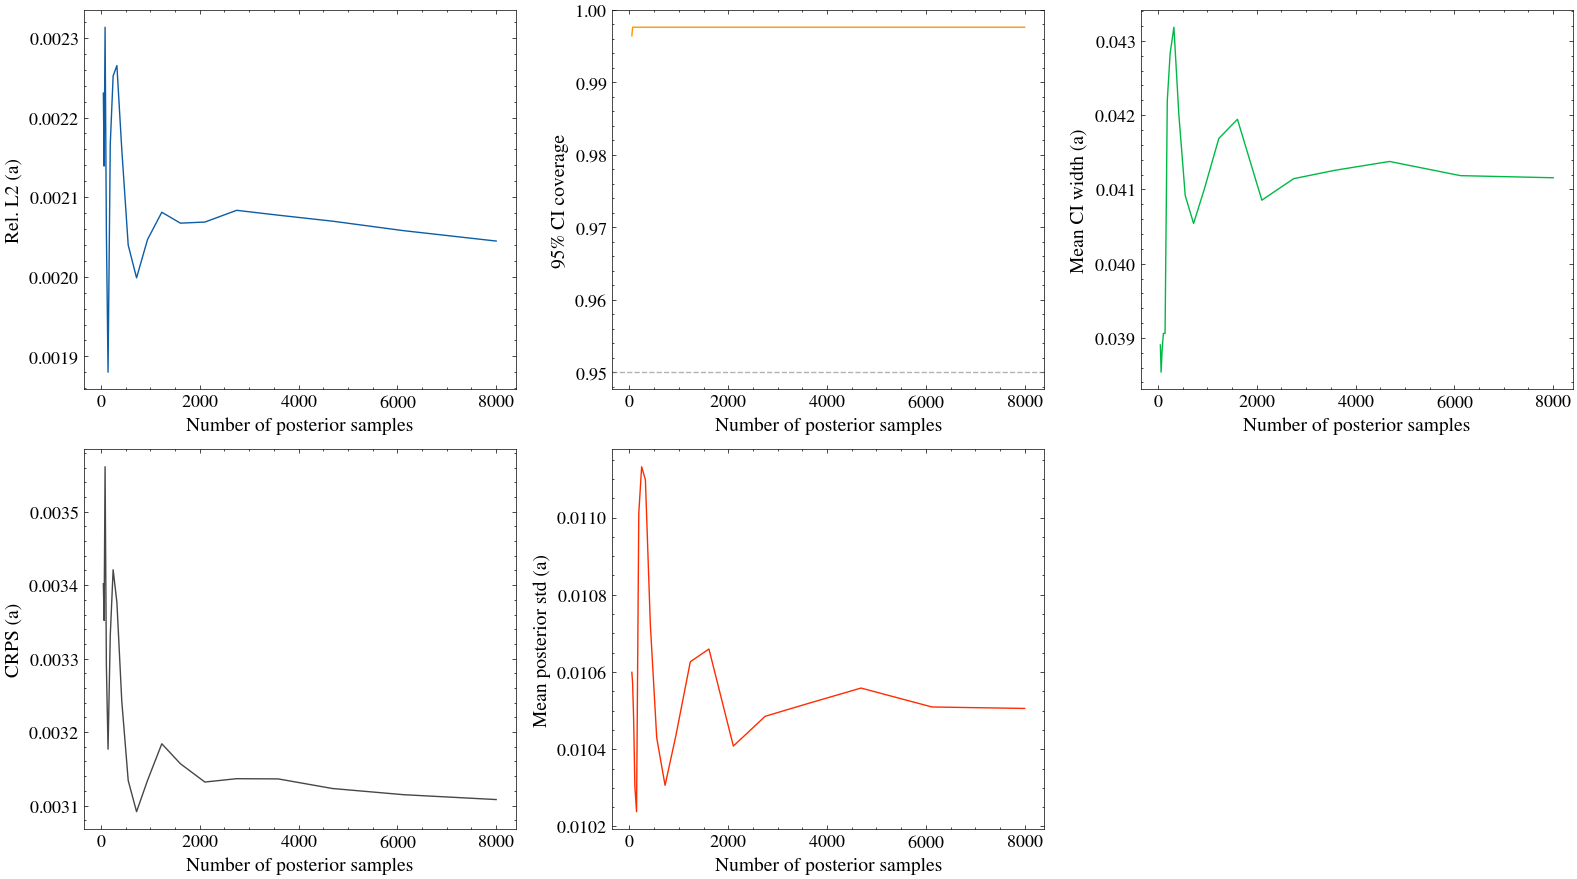

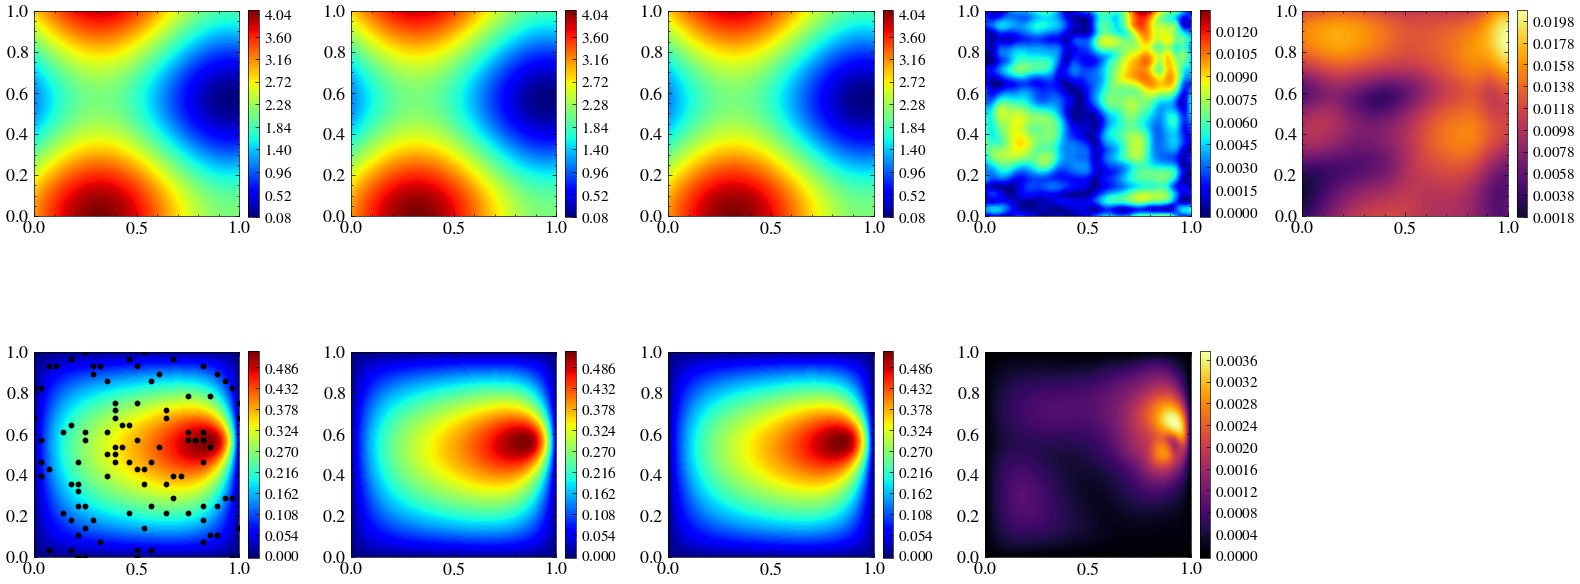

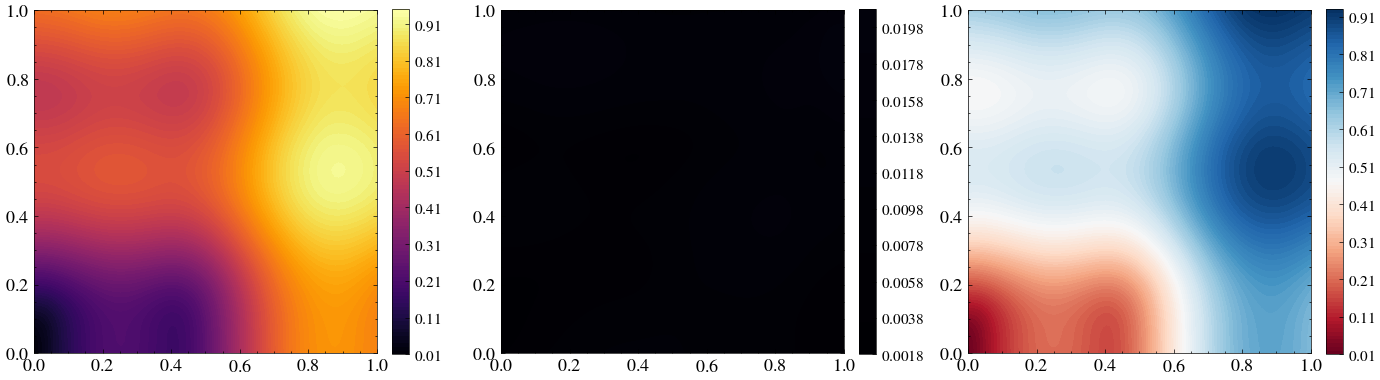

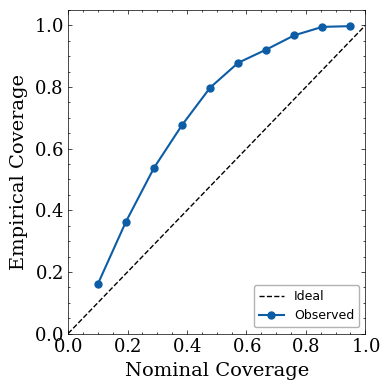

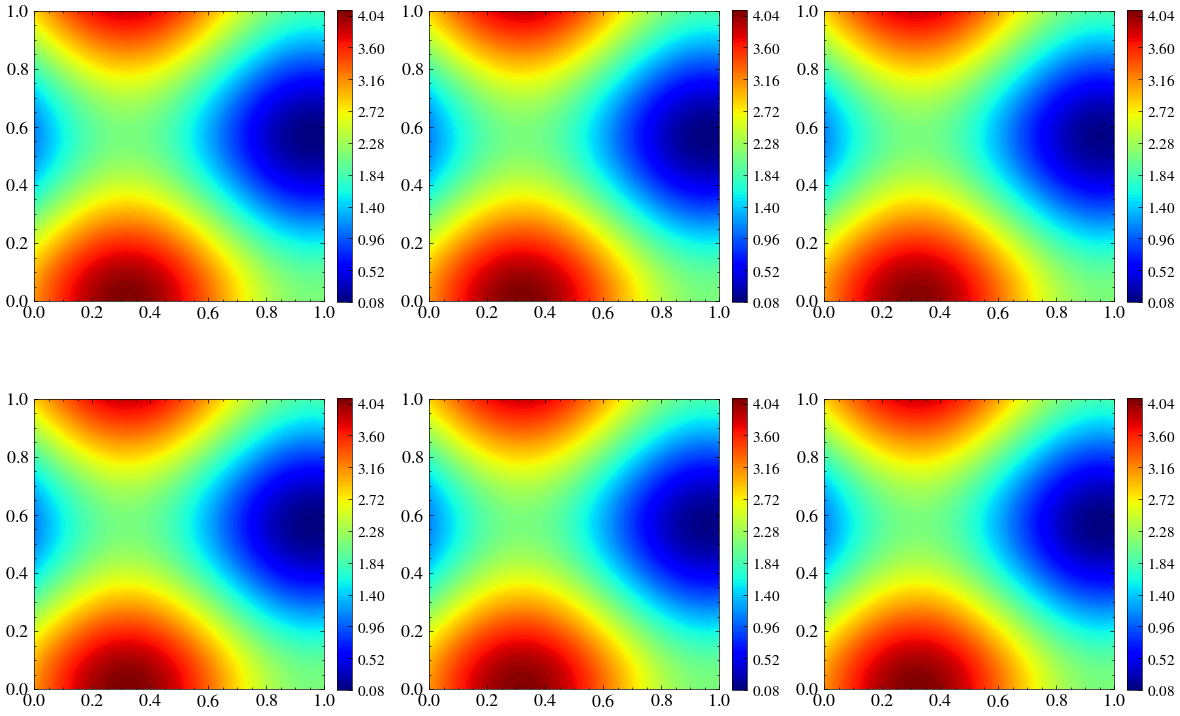

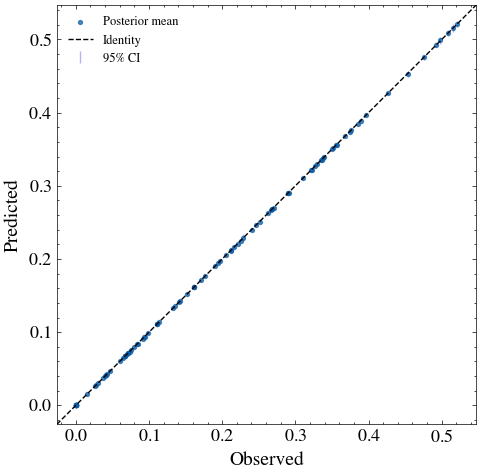

  Chi2 PPC: chi2=0.22, p=1.0000 (df=100)
Spearman rho(|error|, std) = 0.255, p = 6.59e-14
Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0    1444.3    1.0037      0.5346      0.0175
   1    3557.6    1.0018     -0.0475      0.0054
   2    1870.5    1.0032      0.0173      0.0187
   3    1521.1    1.0039     -0.4106      0.0393
   4    1468.1    1.0038     -0.5939      0.0453
   5    1487.3    1.0039     -0.7752      0.0235

Divergences: 1 / 8000 (0.0%)

  RELIABILITY: [PASS] All diagnostics within thresholds


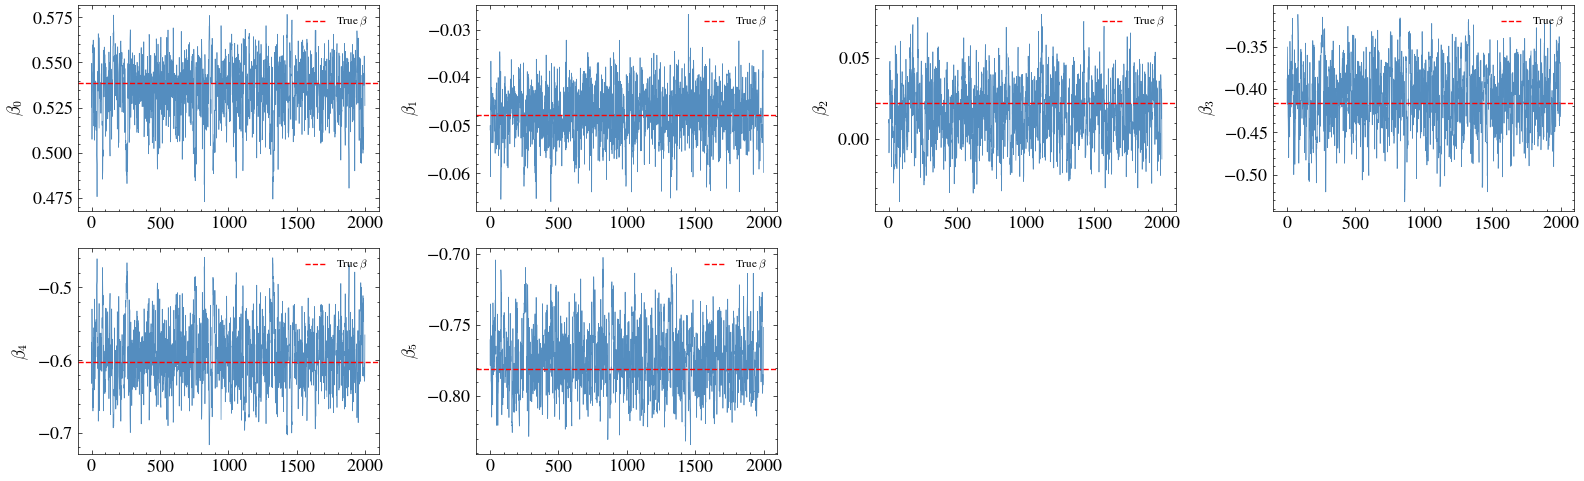

In [6]:
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/baseline_darcy_continuous/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    print(f"x_obs: {x_obs.shape}, u_obs: {u_obs.shape}")
    print(f"a_true range: [{float(a_true.min()):.3f}, {float(a_true.max()):.3f}]")

    # ### Prior Predictive Baseline

    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}, "
          f"CI_width={prior_metrics['ci_width']:.4f}, mean_std={prior_metrics['mean_std']:.4f}")

    # ### Log-likelihood and NumPyro model

    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs)
    numpyro_model = make_numpyro_model(d, log_prior_fn, log_likelihood_fn)

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Sigma Tuning via Pilot MCMC

    def _model_factory(sigma):
        def _model():
            numpyro_model(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            preds = problem.predict_from_beta(params, jnp.array(beta_i), x_full)
            a_preds.append(np.array(preds['a_pred'][0, :, 0]))
        return np.stack(a_preds)

    rng, tune_key = jax.random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
    )
    print(f"sigma (tuned): {SIGMA:.6f}")

    # ### Full MCMC Run

    print(f"Running NUTS: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains ({CHAIN_METHOD}), sigma={SIGMA}")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc, timing = run_mcmc(
        numpyro_model, {"beta": beta_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    mcmc.print_summary()

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_samples = diag['samples']

    # ### Decode Posterior Samples

    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

    a_mean = np.mean(a_pred_all, axis=0)
    a_std  = np.std(a_pred_all,  axis=0)
    u_mean = np.mean(u_pred_all, axis=0)
    u_std  = np.std(u_pred_all,  axis=0)

    print(f"a_pred_all: {a_pred_all.shape}, u_pred_all: {u_pred_all.shape}")

    # ### Metrics

    a_true_np    = np.array(a_true[0, :, 0])
    a_mean_np    = a_mean
    a_map_np     = np.array(a_map[:, 0])
    a_samples_np = a_pred_all

    u_true_np    = np.array(u_true[0, :, 0])
    u_mean_np    = u_mean
    u_map_np     = np.array(u_map[:, 0])
    u_samples_np = u_pred_all

    rmse_post_a = rmse(jnp.array(a_mean_np), jnp.array(a_true_np))
    rmse_post_u = rmse(jnp.array(u_mean_np), jnp.array(u_true_np))

    crps_a = float(np.mean(crps_ensemble(a_samples_np, a_true_np)))
    crps_u = float(np.mean(crps_ensemble(u_samples_np, u_true_np)))

    nll_a = nll_score(a_samples_np, a_true_np)

    cal_levels, cal_empirical = compute_calibration(a_samples_np, a_true_np)

    ci_w = ci_width_95(a_samples_np)

    a_std_np = a_std
    sharpness = float(np.mean(a_std_np))

    plot_metrics_table({
        'MAP RMSE (a)': rmse_map_a,
        'Posterior Mean RMSE (a)': rmse_post_a,
        'MAP RMSE (u)': rmse_map_u,
        'Posterior Mean RMSE (u)': rmse_post_u,
        'CRPS (a)': crps_a,
        'CRPS (u)': crps_u,
        'Mean 95% CI Width (a)': ci_w,
        'Sharpness (mean std)': sharpness,
        'sigma': SIGMA,
    }, title='Darcy Continuous — RQ1 Metrics')

    print("Calibration:")
    for nom, emp in zip(cal_levels, cal_empirical):
        print(f"  Nominal {nom:.0%} -> Empirical {emp:.2%}")

    # ### Statistical Confidence in Metrics

    bs_results = compute_bootstrap_ci_block(a_samples_np, a_true_np)
    format_significance_table({
        'CRPS (a)':         bs_results['crps_a'],
        'Coverage 95% (a)': bs_results['coverage_95'],
        'CI Width 95% (a)': bs_results['ci_width'],
        'Sharpness (a)':    bs_results['sharpness'],
    }, title='RQ1 — Bootstrap CI on Posterior Metrics (Darcy Continuous)')

    chain_metrics = compute_per_chain_metrics(a_samples_np, a_true_np, NUM_CHAINS)
    print_per_chain_table(chain_metrics, NUM_CHAINS)

    # ### Metric Convergence

    conv_result = compute_metric_convergence(a_samples_np, a_true_np)

    from results_schema import ExperimentResult
    from datetime import datetime

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std_np,
        save_path=None,
    )

    run_result = {
        "sigma": SIGMA,
        "ess_min": diag['ess_min'],
        "rhat_max": diag['rhat_max'],
        "rhat_mean": diag['rhat_mean'],
        "n_div": diag['n_div'],
        "reliability_flag": diag['flag'],
        "reliability_explanation": diag['flag_explanation'],
        "a_err": rmse_post_a,
        "u_err": float(rmse_post_u),
        "crps_a": crps_a,
        "nll_a": nll_a,
        "chi2_ppc": chi2_stat,
        "chi2_ppc_pvalue": chi2_pval,
        "coverage_95": float(cal_empirical[-1]),
        "ci_width": float(ci_w),
        "mean_std": sharpness,
        "cal_levels": cal_levels,
        "cal_empirical": cal_empirical,
        "map_a_err": float(rmse_map_a),
        "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": spearman_rho,
        "spearman_pvalue_error_std": spearman_p,
        "warmup_time_s": timing['warmup_time_s'],
        "sampling_time_s": timing['sampling_time_s'],
        "step_time_s": timing['step_time_s'],
    }

    mcmc_result = build_mcmc_result(run_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="baseline",
        problem="darcy_continuous",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=mcmc_result,
        prior=build_prior_result(prior_metrics),
        laplace=None,
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    plot_metric_convergence(
        [conv_result],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # ### Plots

    x_np = np.array(x_full[0])

    plot_field_comparison(
        x_np, a_true_np, a_map_np, a_mean_np, a_std_np,
        grid_shape=(29, 29),
        u_true=u_true_np, u_map=u_map_np, u_mean=u_mean_np, u_std=u_std,
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison.png',
    )

    plot_std_comparison_generic(
        x_np, prior_a_std, a_std_np,
        label_a='Prior', label_b='Posterior',
        grid_shape=(29, 29),
        suptitle='Prior vs Posterior Uncertainty',
        save_path=FIGURE_DIR / 'prior_posterior_std.png',
    )

    plot_calibration(cal_levels, cal_empirical, save_path=FIGURE_DIR / 'calibration.png')

    plot_posterior_gallery(
        x_np, a_samples_np, grid_shape=(29, 29),
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive.png',
    )

    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std_np,
        save_path=FIGURE_DIR / 'error_vs_std.png',
    )
    print(f'Spearman rho(|error|, std) = {spearman_rho:.3f}, p = {spearman_p:.2e}')

    # ### MCMC Diagnostics (Appendix)

    print_dimension_diagnostics(np.array(beta_samples), diag['ess'], diag['rhat'])

    extra_fields = mcmc.get_extra_fields()
    if "diverging" in extra_fields:
        n_div = int(extra_fields["diverging"].sum())
        total = NUM_CHAINS * NUM_SAMPLES
        print(f"\nDivergences: {n_div} / {total} ({n_div/total:.1%})")
    else:
        print("\nDivergence info not available")

    print(f"\n  RELIABILITY: [{diag['flag']}] {diag['flag_explanation']}")

    beta_true_np = np.array(beta_true)
    beta_all_chains = np.array(mcmc.get_samples(group_by_chain=True)["beta"])
    beta_for_trace = beta_all_chains[0]
    plot_trace(beta_for_trace, beta_true_np, num_warmup=0, save_path=FIGURE_DIR / 'trace_plots.png')

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("baseline", "darcy_continuous")

Cross-Seed Summary (12 seeds: [7, 7, 7, 42, 42, 42, 42, 42, 42, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0271      0.0467      0.0017      0.1632
u_err                 0.0263      0.0356      0.0017      0.1208
crps_a                0.0383      0.0673      0.0029      0.2384
coverage_95           0.9761      0.0472      0.8347      1.0000
ci_width              0.3239      0.4121      0.0395      1.3383
mean_std              0.0833      0.1054      0.0100      0.3395
ess_min            1051.8405    944.7755     79.8117   2689.8224
rhat_max              1.0165      0.0194      1.0015      1.0643
n_div                23.5000     28.3821      0.0000     66.0000
